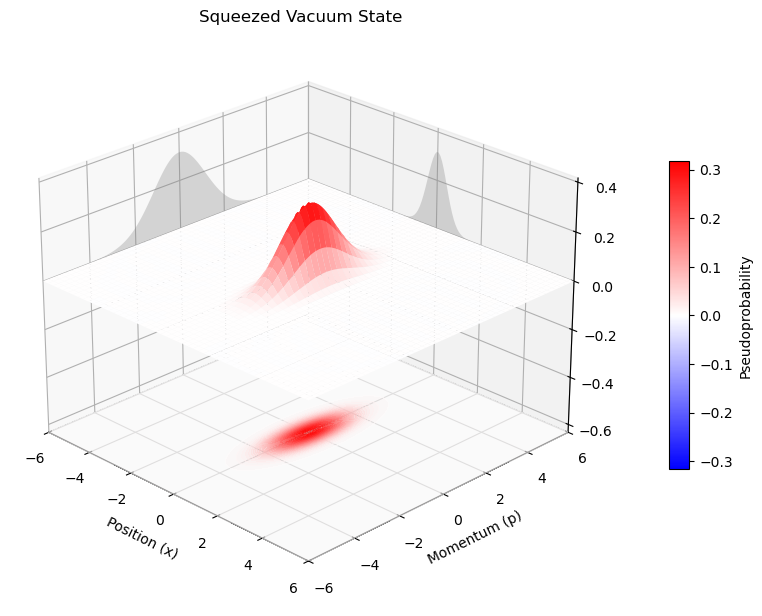

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection # 畫投影
from qutip import *

dim = 25
sp = 0.5

ground = basis(dim, 0)
squeezed_vacuum_state = squeeze(dim, sp) * ground



# -------------------------------------------------
xvec = np.linspace(-6, 6, 150)
X, Y = np.meshgrid(xvec, xvec)
W = wigner(squeezed_vacuum_state, xvec, xvec)

w_max = np.max(np.abs(W))

fig = plt.figure(figsize= (10, 8))
ax = fig.add_subplot(111, projection= '3d')

x_min, x_max = -6, 6
y_min, y_max = -6, 6
z_min = -2*w_max  # Z 軸底部
z_max = w_max + 0.1

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)


surf = ax.plot_surface(X, Y, W, cmap='bwr', linewidth=0, edgecolor='none', antialiased=True, vmin=-w_max, vmax=w_max)

# Colorbar
cbar = fig.colorbar(surf, ax= ax, shrink= 0.5, aspect= 15, pad= 0.1)
cbar.set_label('Pseudoprobability')

# 底部投影
levels_bottom = np.linspace(-w_max, w_max, 100)
ax.contourf(X, Y, W, zdir= 'z', offset= z_min, levels= levels_bottom, cmap= 'bwr', alpha= 0.6, vmin= -w_max, vmax= w_max)

# 側邊投影
W_proj_y = np.max(W, axis=0)  # 在 X 軸方向
W_proj_x = np.max(W, axis=1)  # 在 Y 軸方向

verts_y = [(xvec[0], 0)] + list(zip(xvec, W_proj_y)) + [(xvec[-1], 0)]
verts_x = [(xvec[0], 0)] + list(zip(xvec, W_proj_x)) + [(xvec[-1], 0)]

poly_y = PolyCollection([verts_y], facecolors= 'gray', alpha= 0.3, edgecolors= 'none')
ax.add_collection3d(poly_y, zs= y_max, zdir= 'y')
poly_x = PolyCollection([verts_x], facecolors= 'gray', alpha= 0.3, edgecolors= 'none')
ax.add_collection3d(poly_x, zs= x_min, zdir= 'x')

ax.view_init(elev=25, azim= -45)
ax.set_title('Squeezed Vacuum State', pad=2)
ax.set_xlabel('Position (x)')
ax.set_ylabel('Momentum (p)')

plt.show()

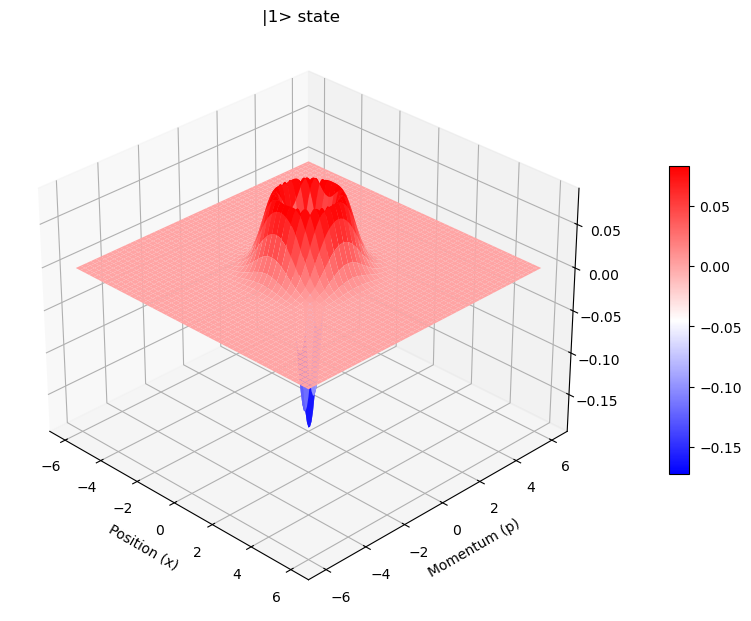

In [184]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# global parameter
dim = 25
sp = 0.1

# state
ground = basis(dim, 0)

a_dagger = create(dim)
one_state = a_dagger * ground

# plot
xvec = np.linspace(-6, 6, 150)
X, Y = np.meshgrid(xvec, xvec)

W = wigner(one_state, xvec, xvec)

fig = plt.figure(figsize= (10, 8))
ax = fig.add_subplot(111, projection= '3d')
surf = ax.plot_surface(X, Y, W, cmap= 'bwr', linewidth= 0, antialiased= True)
ax.view_init(elev= 30, azim= -45)

# Colorbar
cbar = fig.colorbar(surf, ax= ax, shrink= 0.5, aspect= 15, pad= 0.1)

ax.set_title('|1> state')
ax.set_xlabel('Position (x)')
ax.set_ylabel('Momentum (p)')

plt.show()

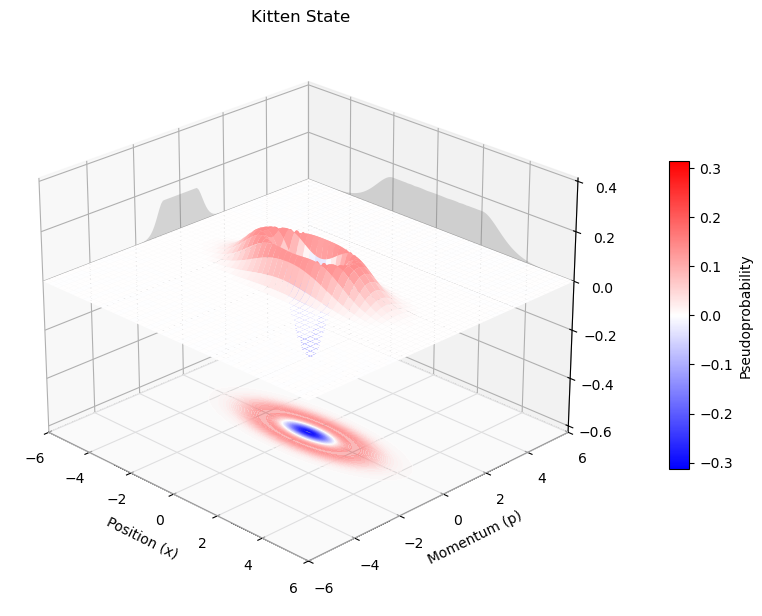

In [185]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from qutip import *

# global parameter
dim = 50
sp = 1
r = 0.5
theta = np.pi 
xi = r * np.exp(1j * theta)

ground = basis(dim)
squeezed_vacuum_state = squeeze(dim, xi) * ground

a_dagger = create(dim)
kitten_state = (a_dagger * squeezed_vacuum_state).unit()

# -------------------------------------------------
xvec = np.linspace(-6, 6, 150)
X, Y = np.meshgrid(xvec, xvec)
W = wigner(kitten_state, xvec, xvec)

w_max = np.max(np.abs(W))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x_min, x_max = -6, 6
y_min, y_max = -6, 6
z_min = -2*w_max  # Z 軸底部
z_max = w_max + 0.1

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)


surf = ax.plot_surface(X, Y, W, cmap='bwr', linewidth=0, edgecolor='none', antialiased=True, vmin=-w_max, vmax=w_max)

# Colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, pad=0.1)
cbar.set_label('Pseudoprobability')

# 底部投影
levels_bottom = np.linspace(-w_max, w_max, 100)
ax.contourf(X, Y, W, zdir='z', offset=z_min, levels=levels_bottom, cmap='bwr', alpha=0.6, vmin=-w_max, vmax=w_max)

# 側邊投影
W_proj_y = np.max(W, axis=0)  # 在 X 軸方向
W_proj_x = np.max(W, axis=1)  # 在 Y 軸方向

verts_y = [(xvec[0], 0)] + list(zip(xvec, W_proj_y)) + [(xvec[-1], 0)]
verts_x = [(xvec[0], 0)] + list(zip(xvec, W_proj_x)) + [(xvec[-1], 0)]

poly_y = PolyCollection([verts_y], facecolors='gray', alpha=0.3, edgecolors='none')
ax.add_collection3d(poly_y, zs=y_max, zdir='y')
poly_x = PolyCollection([verts_x], facecolors='gray', alpha=0.3, edgecolors='none')
ax.add_collection3d(poly_x, zs=x_min, zdir='x')

ax.view_init(elev=25, azim=-45)
ax.set_title('Kitten State', pad=2)
ax.set_xlabel('Position (x)')
ax.set_ylabel('Momentum (p)')

plt.show()